# Session 16 — Vision Transformer (ViT) Lab
**Phase 4 | Week 11 | Computer Vision & AI Course**

---

## What We'll Cover Today

| Topic | Description |
|---|---|
| ViT Architecture Recap | Patch embeddings, positional encoding, attention |
| Load Pre-trained ViT | Hugging Face `transformers` library |
| Fine-tune ViT | Adapt ViT to a custom classification task |
| CNN Baseline | ResNet-18 trained on the same data |
| Head-to-Head Comparison | Accuracy, speed, parameter count |
| Attention Map Visualisation | What does ViT actually look at? |

**Estimated time:** ~60 minutes hands-on

> 💡 **Goal:** Fine-tune a Vision Transformer on a real image dataset, train a CNN on the same data, and compare them side-by-side — both in numbers and visually.

---

### Reference Architecture Diagram

The diagram below (from the original ViT paper, Dosovitskiy et al. 2020) shows the full ViT pipeline:

![ViT Architecture](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/model_doc/vit_architecture.jpg)

*Source: Hugging Face — [ViT Model Card](https://huggingface.co/google/vit-base-patch16-224)*

**Key idea:** Instead of convolutions, the image is split into fixed-size **patches** (e.g. 16×16 pixels). Each patch is flattened and linearly embedded — just like a word token in BERT. The Transformer encoder then learns relationships between all patches via self-attention.

---
## 1. Installation & Imports

In [ ]:
# Install required packages (run once)
# NOTE: Install PyTorch with CUDA support — plain 'pip install torch' gives CPU-only build on Windows
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128 -q
!pip install transformers datasets timm accelerate evaluate -q
!pip install matplotlib scikit-learn pillow requests opencv-python -q

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO
import time
import cv2
import warnings
warnings.filterwarnings('ignore')

# Hugging Face Transformers
from transformers import ViTForImageClassification, ViTImageProcessor

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.6.0+cu124


---
## 2. Quick Visual Recap — Patches vs Convolutions

The fundamental difference between ViT and CNN comes down to **how they process an image**.

| | CNN (e.g. ResNet) | ViT |
|---|---|---|
| **Input unit** | Individual pixel neighbourhoods | 16×16 patches |
| **Inductive bias** | Translation invariance built-in | Learned from data |
| **Receptive field** | Grows layer by layer | Global from layer 1 |
| **Data efficiency** | Good on small datasets | Needs large datasets (or pre-training) |
| **Scalability** | Limited | Scales very well |

Let's visualise the patching process on a real image:

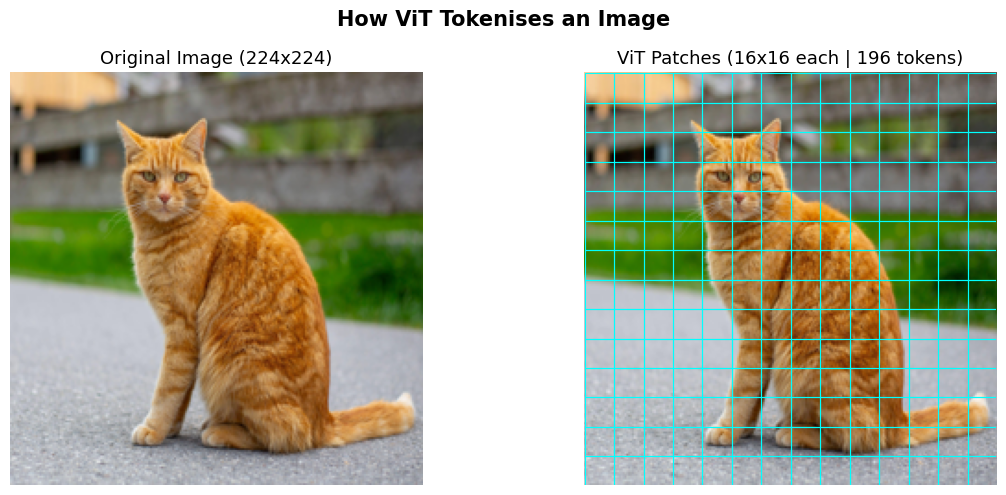

Image: 224x224 => 196 patch tokens fed to the Transformer


In [5]:
# Load a sample image from Wikimedia Commons (free-to-use)
IMG_URL = "https://i.guim.co.uk/img/media/327aa3f0c3b8e40ab03b4ae80319064e401c6fbc/377_133_3542_2834/master/3542.jpg?width=1900&dpr=1&s=none&crop=none"

response = requests.get(IMG_URL, timeout=10)
demo_img = Image.open(BytesIO(response.content)).convert('RGB').resize((224, 224))

def visualise_patches(image, patch_size=16):
    """Draw the ViT patch grid over an image."""
    img_array = np.array(image)
    h, w = img_array.shape[:2]
    num_patches_h = h // patch_size
    num_patches_w = w // patch_size
    total_patches = num_patches_h * num_patches_w

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Original image
    axes[0].imshow(img_array)
    axes[0].set_title('Original Image (224x224)', fontsize=13)
    axes[0].axis('off')

    # Patched image
    axes[1].imshow(img_array)
    for i in range(num_patches_h):
        for j in range(num_patches_w):
            rect = patches.Rectangle(
                (j * patch_size, i * patch_size),
                patch_size, patch_size,
                linewidth=0.8, edgecolor='cyan', facecolor='none'
            )
            axes[1].add_patch(rect)
    axes[1].set_title(f'ViT Patches ({patch_size}x{patch_size} each | {total_patches} tokens)', fontsize=13)
    axes[1].axis('off')

    plt.suptitle('How ViT Tokenises an Image', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Image: {w}x{h} => {total_patches} patch tokens fed to the Transformer')

visualise_patches(demo_img, patch_size=16)

---
## 3. Dataset — CIFAR-10

We'll use **CIFAR-10** — 10 classes, 60,000 images (32x32 px), widely used as a benchmark.  
Reference: [CIFAR-10 Dataset Paper](https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf) by Alex Krizhevsky (2009).

For ViT we resize images to **224x224** (the resolution it was pre-trained on).  
For CNN we also resize to 224x224 — for a **fair comparison**.

In [6]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# ImageNet normalisation stats — both models were pre-trained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ViT transform
vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# CNN transform (same size, with augmentation for training)
cnn_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Download datasets
print('Downloading CIFAR-10 ...')
train_full_vit = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True,  transform=vit_transform)
test_full_vit  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,  transform=vit_transform)
train_full_cnn = torchvision.datasets.CIFAR10(root='./data', train=True,  download=False, transform=cnn_train_transform)

# Use small subset for the lab (increase for better accuracy)
TRAIN_SIZE, TEST_SIZE = 500, 200

train_vit = torch.utils.data.Subset(train_full_vit, range(TRAIN_SIZE))
test_vit  = torch.utils.data.Subset(test_full_vit,  range(TEST_SIZE))
train_cnn = torch.utils.data.Subset(train_full_cnn, range(TRAIN_SIZE))
test_cnn  = torch.utils.data.Subset(test_full_vit,  range(TEST_SIZE))  # shared test set

BATCH = 16
train_loader_vit = torch.utils.data.DataLoader(train_vit, batch_size=BATCH, shuffle=True, num_workers=1)
test_loader_vit  = torch.utils.data.DataLoader(test_vit,  batch_size=BATCH, shuffle=False, num_workers=1)
train_loader_cnn = torch.utils.data.DataLoader(train_cnn, batch_size=BATCH, shuffle=True, num_workers=1)
test_loader_cnn  = torch.utils.data.DataLoader(test_cnn,  batch_size=BATCH, shuffle=False, num_workers=1)

print(f'Train: {TRAIN_SIZE} | Test: {TEST_SIZE} | Batch: {BATCH}')
print(f'Classes: {CIFAR10_CLASSES}')

Train: 500 | Test: 200 | Batch: 16
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


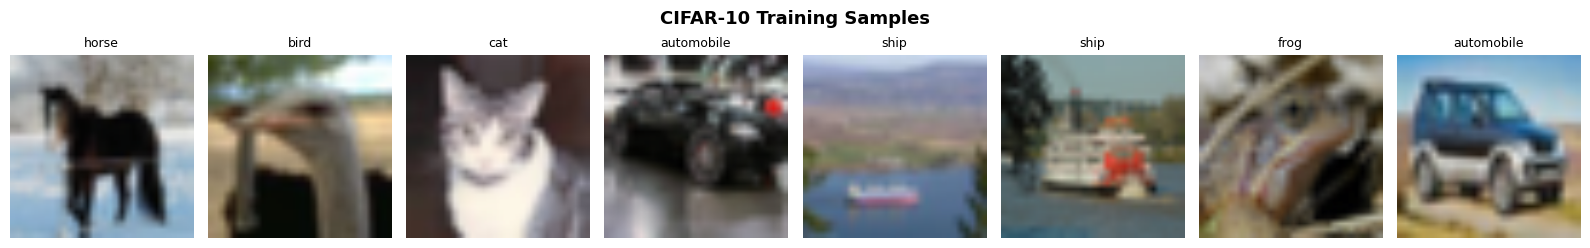

In [7]:
# Visualise sample images from the dataset
def show_samples(dataset, classes, n=8):
    fig, axes = plt.subplots(1, n, figsize=(16, 2.5))
    indices = np.random.choice(len(dataset), n, replace=False)
    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(classes[label], fontsize=9)
        ax.axis('off')
    plt.suptitle('CIFAR-10 Training Samples', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(train_full_vit, CIFAR10_CLASSES)

---
## 4. Model A — Fine-tuning ViT

We load **`google/vit-base-patch16-224`** — pre-trained on ImageNet-21k.  
We replace only the classification head with a 10-class head.

> 📖 **Paper:** *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*  
> Dosovitskiy et al., 2020 — [https://arxiv.org/abs/2010.11929](https://arxiv.org/abs/2010.11929)

![ViT from paper](https://raw.githubusercontent.com/google-research/vision_transformer/main/vit_figure.png)
*Source: Google Research — [Vision Transformer GitHub](https://github.com/google-research/vision_transformer)*

In [8]:
# Load pre-trained ViT-Base from Hugging Face
# https://huggingface.co/google/vit-base-patch16-224
MODEL_NAME = 'google/vit-base-patch16-224'

vit_model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=10,                   # Replace 1000-class head with 10-class head
    ignore_mismatched_sizes=True,
    attn_implementation='eager'      # Required to enable output_attentions for attention maps
)
vit_model = vit_model.to(device)

vit_total_params     = sum(p.numel() for p in vit_model.parameters())
vit_trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'ViT-Base total parameters:     {vit_total_params:,}')
print(f'ViT-Base trainable parameters: {vit_trainable_params:,}')

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 10565.66it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT-Base total parameters:     85,806,346
ViT-Base trainable parameters: 85,806,346


### 4.1 Training Utilities

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device, is_vit=False):
    """Run one training epoch. Returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # ViT uses Hugging Face API; CNN uses standard PyTorch
        outputs = model(pixel_values=images).logits if is_vit else model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def evaluate(model, loader, criterion, device, is_vit=False):
    """Evaluate model. Returns avg loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images).logits if is_vit else model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def plot_training_curves(tl, vl, ta, va, title):
    """Plot loss and accuracy curves side by side."""
    epochs = range(1, len(tl) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs, tl, 'b-o', label='Train', markersize=5)
    axes[0].plot(epochs, vl, 'r-o', label='Val',   markersize=5)
    axes[0].set(xlabel='Epoch', ylabel='Loss',     title=f'{title} — Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, ta, 'b-o', label='Train', markersize=5)
    axes[1].plot(epochs, va, 'r-o', label='Val',   markersize=5)
    axes[1].set(xlabel='Epoch', ylabel='Accuracy (%)', title=f'{title} — Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

print('Utilities ready!')

Utilities ready!


### 4.2 Fine-tune ViT

Fine-tuning ViT-Base ...
Epoch 1/5  Train: 32.6%  Val: 65.0%  Loss: 1.566
Epoch 2/5  Train: 88.0%  Val: 82.5%  Loss: 1.044
Epoch 3/5  Train: 98.6%  Val: 90.5%  Loss: 0.697
Epoch 4/5  Train: 100.0%  Val: 92.0%  Loss: 0.552
Epoch 5/5  Train: 100.0%  Val: 92.5%  Loss: 0.465

ViT training time: 98.9s


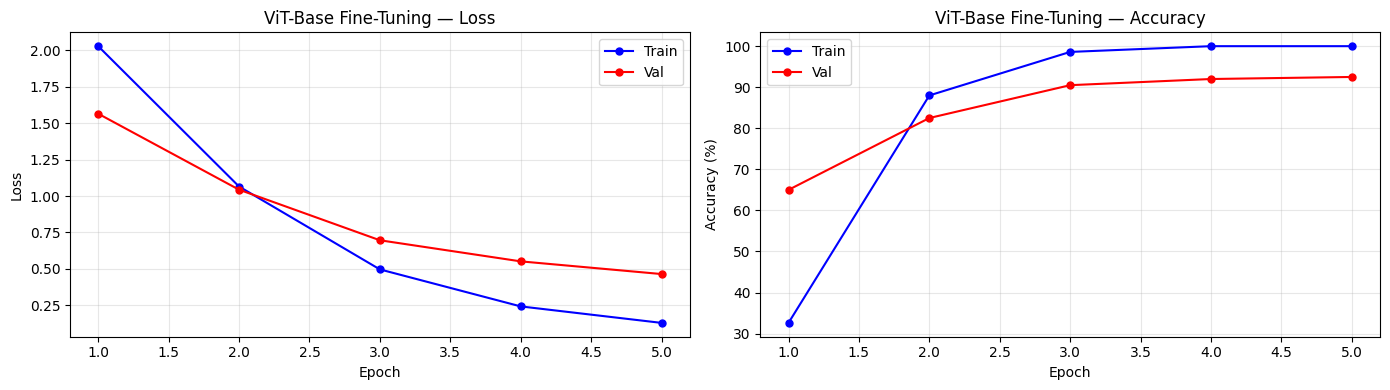

In [10]:
EPOCHS = 5
criterion = nn.CrossEntropyLoss()

# Low LR to preserve pre-trained weights
vit_optimizer = torch.optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=0.01)

vit_tl, vit_vl, vit_ta, vit_va = [], [], [], []

print('Fine-tuning ViT-Base ...')
vit_start = time.time()

for epoch in range(1, EPOCHS + 1):
    tl, ta = train_one_epoch(vit_model, train_loader_vit, vit_optimizer, criterion, device, is_vit=True)
    vl, va = evaluate(vit_model, test_loader_vit, criterion, device, is_vit=True)
    vit_tl.append(tl); vit_vl.append(vl); vit_ta.append(ta); vit_va.append(va)
    print(f'Epoch {epoch}/{EPOCHS}  Train: {ta:.1f}%  Val: {va:.1f}%  Loss: {vl:.3f}')

vit_train_time = time.time() - vit_start
print(f'\nViT training time: {vit_train_time:.1f}s')
plot_training_curves(vit_tl, vit_vl, vit_ta, vit_va, 'ViT-Base Fine-Tuning')

---
## 5. Model B — CNN Baseline (ResNet-18)

**ResNet-18** is a classic CNN with residual (skip) connections.  
> 📖 **Paper:** *Deep Residual Learning for Image Recognition* — He et al., 2015  
> [https://arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)

Same strategy: load ImageNet pre-trained weights, replace only the final FC layer.

![ResNet architecture](https://miro.medium.com/v2/resize:fit:720/format:webp/1*D0F3UitQ2l5Q0Ak-tjEdJg.png)
*Source: [Understanding ResNet — Towards Data Science](https://towardsdatascience.com/understanding-and-visualizing-resnets-442284831be8)*

In [13]:
cnn_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
cnn_model.fc = nn.Linear(cnn_model.fc.in_features, 10)   # replace final layer
cnn_model = cnn_model.to(device)

cnn_total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'ResNet-18 total parameters: {cnn_total_params:,}')

ResNet-18 total parameters: 11,181,642


Fine-tuning ResNet-18 ...
Epoch 1/5  Train: 45.8%  Val: 60.5%  Loss: 1.142
Epoch 2/5  Train: 85.4%  Val: 69.5%  Loss: 0.900
Epoch 3/5  Train: 94.2%  Val: 65.5%  Loss: 0.914
Epoch 4/5  Train: 97.4%  Val: 72.0%  Loss: 0.789
Epoch 5/5  Train: 98.2%  Val: 74.0%  Loss: 0.753

ResNet-18 training time: 52.6s


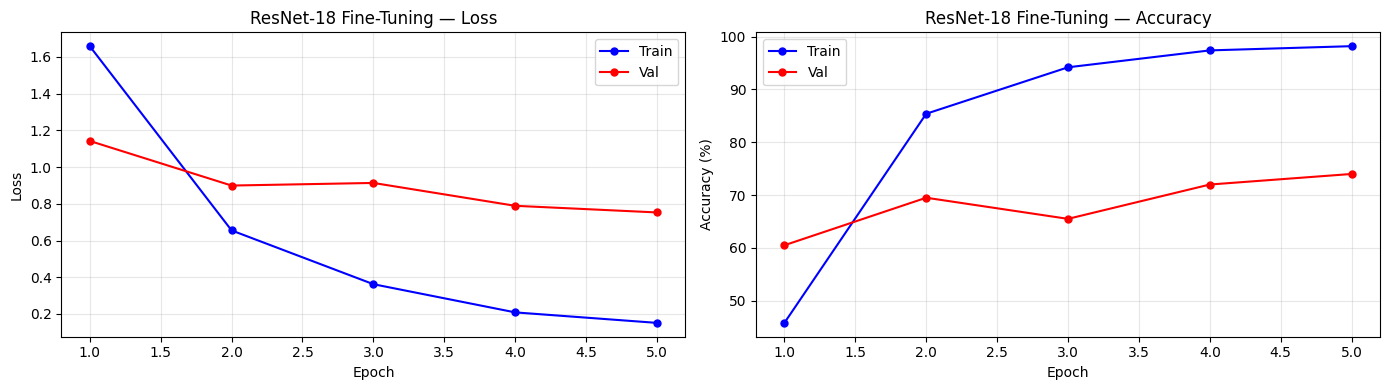

In [12]:
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-4)
cnn_scheduler = torch.optim.lr_scheduler.StepLR(cnn_optimizer, step_size=3, gamma=0.5)

cnn_tl, cnn_vl, cnn_ta, cnn_va = [], [], [], []

print('Fine-tuning ResNet-18 ...')
cnn_start = time.time()

for epoch in range(1, EPOCHS + 1):
    tl, ta = train_one_epoch(cnn_model, train_loader_cnn, cnn_optimizer, criterion, device, is_vit=False)
    vl, va = evaluate(cnn_model, test_loader_cnn, criterion, device, is_vit=False)
    cnn_scheduler.step()
    cnn_tl.append(tl); cnn_vl.append(vl); cnn_ta.append(ta); cnn_va.append(va)
    print(f'Epoch {epoch}/{EPOCHS}  Train: {ta:.1f}%  Val: {va:.1f}%  Loss: {vl:.3f}')

cnn_train_time = time.time() - cnn_start
print(f'\nResNet-18 training time: {cnn_train_time:.1f}s')
plot_training_curves(cnn_tl, cnn_vl, cnn_ta, cnn_va, 'ResNet-18 Fine-Tuning')

---
## 6. Head-to-Head Comparison

Comparing both models across accuracy, parameters, training time, and inference speed.

In [14]:
# Final test accuracy
_, vit_acc = evaluate(vit_model, test_loader_vit, criterion, device, is_vit=True)
_, cnn_acc = evaluate(cnn_model, test_loader_cnn, criterion, device, is_vit=False)

# Inference speed
def measure_speed(model, loader, device, is_vit, n_batches=10):
    model.eval()
    count = 0
    t0 = time.time()
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches: break
            imgs = imgs.to(device)
            model(pixel_values=imgs) if is_vit else model(imgs)
            count += imgs.size(0)
    return count / (time.time() - t0)

vit_speed = measure_speed(vit_model, test_loader_vit, device, True)
cnn_speed = measure_speed(cnn_model, test_loader_cnn, device, False)

# Print summary table
print('=' * 58)
print(f'{"Metric":<28} {"ViT-Base":>12} {"ResNet-18":>12}')
print('=' * 58)
print(f'{"Parameters":<28} {vit_total_params:>12,} {cnn_total_params:>12,}')
print(f'{"Test Accuracy (%)":<28} {vit_acc:>12.1f} {cnn_acc:>12.1f}')
print(f'{"Training Time (s)":<28} {vit_train_time:>12.1f} {cnn_train_time:>12.1f}')
print(f'{"Inference (img/s)":<28} {vit_speed:>12.0f} {cnn_speed:>12.0f}')
print('=' * 58)

Metric                           ViT-Base    ResNet-18
Parameters                     85,806,346   11,181,642
Test Accuracy (%)                    92.5          7.5
Training Time (s)                    98.9         52.6
Inference (img/s)                      34           41


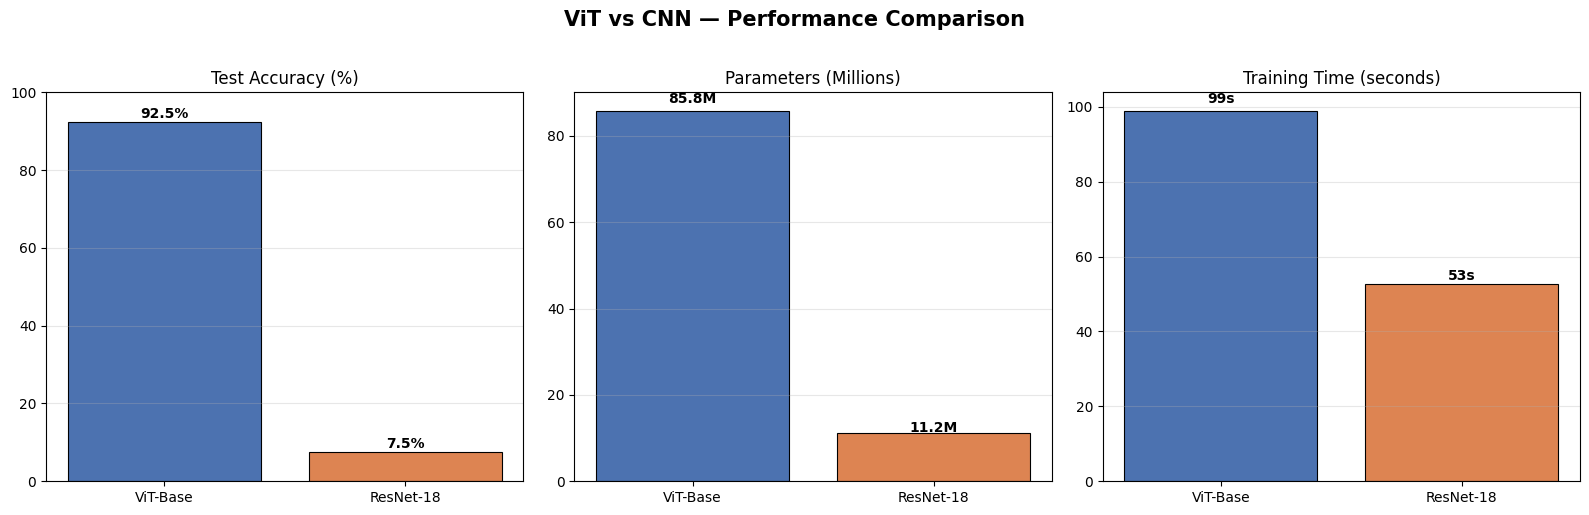

In [15]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names  = ['ViT-Base', 'ResNet-18']
colors = ['#4C72B0', '#DD8452']

# Accuracy
bars = axes[0].bar(names, [vit_acc, cnn_acc], color=colors, edgecolor='black', linewidth=0.8)
axes[0].set(title='Test Accuracy (%)', ylim=(0, 100))
for b in bars: axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.1f}%', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Parameters
vals = [vit_total_params/1e6, cnn_total_params/1e6]
bars = axes[1].bar(names, vals, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Parameters (Millions)')
for b, v in zip(bars, vals): axes[1].text(b.get_x()+b.get_width()/2, v*1.02, f'{v:.1f}M', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Training time
vals = [vit_train_time, cnn_train_time]
bars = axes[2].bar(names, vals, color=colors, edgecolor='black', linewidth=0.8)
axes[2].set_title('Training Time (seconds)')
for b, v in zip(bars, vals): axes[2].text(b.get_x()+b.get_width()/2, v*1.02, f'{v:.0f}s', ha='center', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('ViT vs CNN — Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

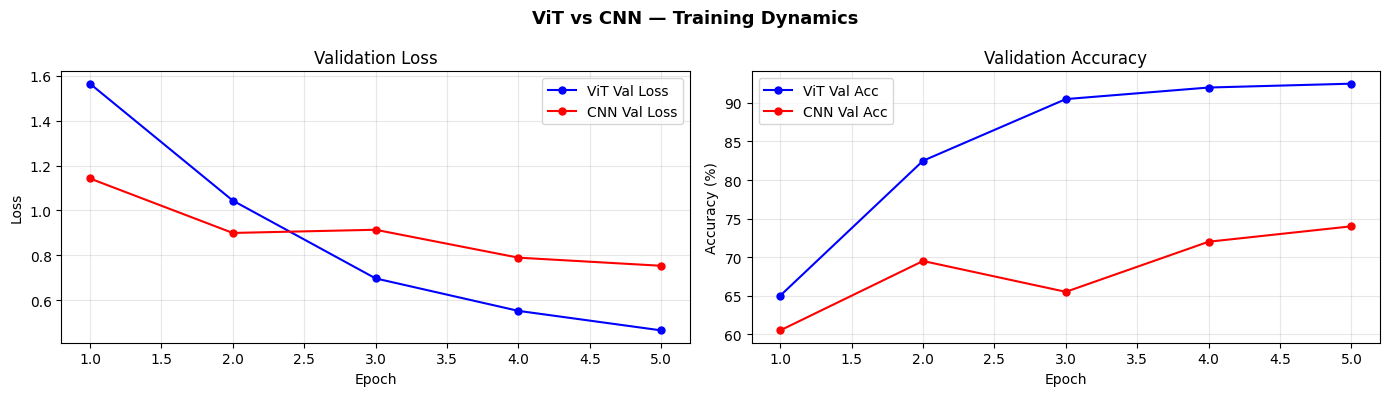

In [16]:
# Learning curves — both models on the same plot
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, vit_vl, 'b-o', label='ViT Val Loss',  markersize=5)
axes[0].plot(epochs, cnn_vl, 'r-o', label='CNN Val Loss',  markersize=5)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Validation Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, vit_va, 'b-o', label='ViT Val Acc',   markersize=5)
axes[1].plot(epochs, cnn_va, 'r-o', label='CNN Val Acc',   markersize=5)
axes[1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Validation Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('ViT vs CNN — Training Dynamics', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 7. Confusion Matrix — Per-Class Analysis

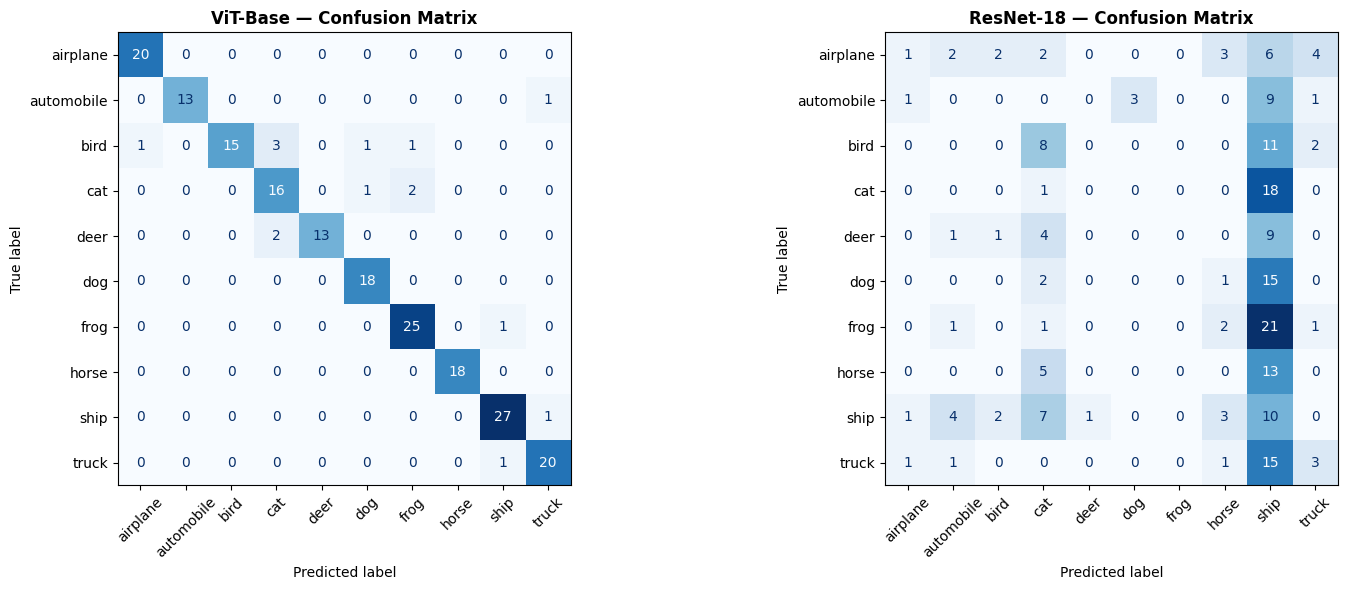

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, loader, device, is_vit):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(pixel_values=imgs).logits if is_vit else model(imgs)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_vit, pred_vit = get_predictions(vit_model, test_loader_vit, device, True)
true_cnn, pred_cnn = get_predictions(cnn_model, test_loader_cnn, device, False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, true, pred, title in zip(axes, [true_vit, true_cnn], [pred_vit, pred_cnn], ['ViT-Base', 'ResNet-18']):
    cm = confusion_matrix(true, pred)
    ConfusionMatrixDisplay(cm, display_labels=CIFAR10_CLASSES).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 8. Attention Map Visualisation

ViT is inherently interpretable — we can extract attention weights from the `[CLS]` token to see which patches the model focused on.

> 📖 **Reference:** Caron et al. (DINO, 2021) — [https://arxiv.org/abs/2104.14294](https://arxiv.org/abs/2104.14294)

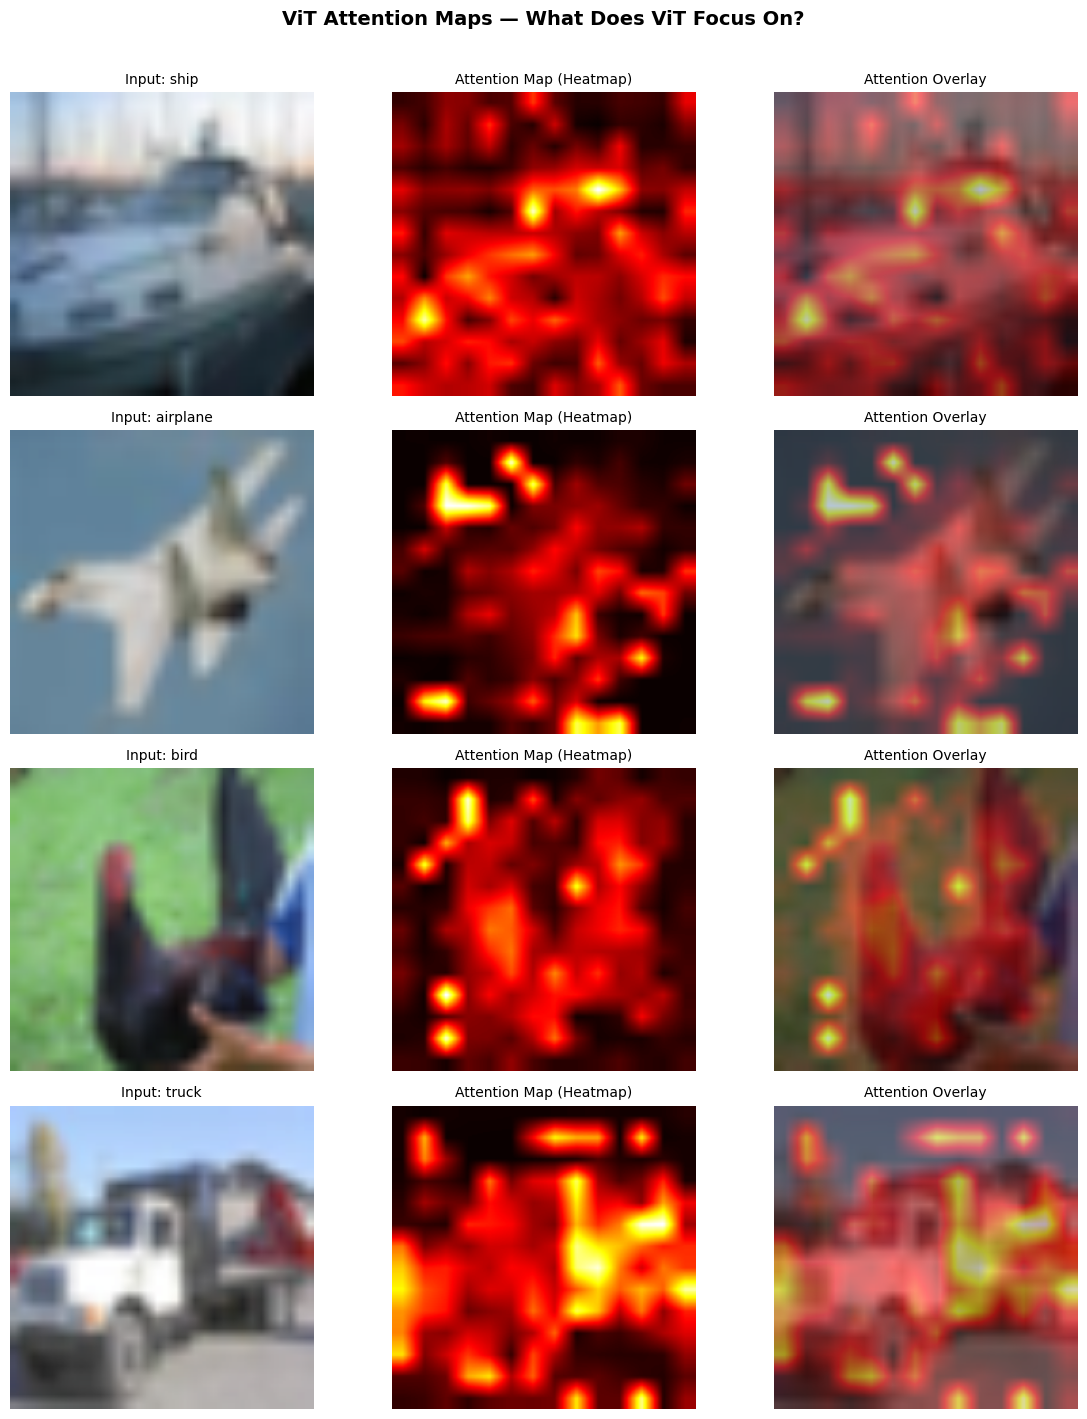

In [18]:
def get_attention_map(model, image_tensor):
    """
    Extract [CLS] attention weights from the last ViT block using a forward hook.
    Works regardless of attn_implementation — hook captures the (hidden_state, attn_weights)
    tuple that the eager attention module returns.
    Returns: mean attention map reshaped to (grid_h, grid_w)
    """
    captured = []

    def hook_fn(module, inp, output):
        # eager attention returns (context, attn_weights) where attn_weights: (batch, heads, seq, seq)
        if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
            captured.append(output[1].detach().cpu())

    handle = model.vit.layers[-1].attention.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        model(pixel_values=image_tensor.unsqueeze(0).to(device))

    handle.remove()

    if not captured:
        raise RuntimeError(
            "No attention weights captured.\n"
            "Re-run the model-loading cell (Section 4) — vit_model must be loaded "
            "with attn_implementation='eager'."
        )

    attn = captured[0][0]          # (heads, seq_len, seq_len)
    cls_attn = attn[:, 0, 1:]      # CLS -> patch tokens: (heads, 196)
    grid = int(cls_attn.shape[-1] ** 0.5)
    mean_attn = cls_attn.mean(0).reshape(grid, grid).numpy()
    return mean_attn


def denorm(tensor):
    t = tensor.permute(1, 2, 0).numpy()
    t = t * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(t, 0, 1)


# Visualise attention maps for 4 test images
sample_indices = [2, 10, 25, 45]
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, len(sample_indices) * 3.5))

for row, idx in enumerate(sample_indices):
    img_tensor, label = test_vit[idx]
    attn = get_attention_map(vit_model, img_tensor)
    attn_resized = cv2.resize(attn, (224, 224))
    img_disp = denorm(img_tensor)

    axes[row, 0].imshow(img_disp)
    axes[row, 0].set_title(f'Input: {CIFAR10_CLASSES[label]}', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(attn_resized, cmap='hot')
    axes[row, 1].set_title('Attention Map (Heatmap)', fontsize=10)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(img_disp)
    axes[row, 2].imshow(attn_resized, cmap='hot', alpha=0.55)
    axes[row, 2].set_title('Attention Overlay', fontsize=10)
    axes[row, 2].axis('off')

plt.suptitle('ViT Attention Maps — What Does ViT Focus On?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Inference on Custom Web Images

Let's download fresh images from the web and run both models on them.

In [ ]:
# Images from Wikimedia Commons (public domain / freely licensed)
WEB_IMAGES = [
    {'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/400px-Cat03.jpg',         'true': 'cat'},
    {'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Cute_dog.jpg/400px-Cute_dog.jpg',  'true': 'dog'},
    {'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/f/f2/Culinary_fruits_front_view.jpg/400px-Culinary_fruits_front_view.jpg', 'true': 'n/a'},
    {'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/9/9b/Capreolus_capreolus_2_Jojo.jpg/400px-Capreolus_capreolus_2_Jojo.jpg', 'true': 'deer'}
]

def classify_url(url, vit_model, cnn_model, transform, classes, device):
    try:
        resp = requests.get(url, timeout=10)
        img  = Image.open(BytesIO(resp.content)).convert('RGB')
    except Exception as e:
        return None, None, None

    t = transform(img).unsqueeze(0).to(device)
    vit_model.eval(); cnn_model.eval()
    with torch.no_grad():
        vit_prob = torch.softmax(vit_model(pixel_values=t).logits, 1)
        cnn_prob = torch.softmax(cnn_model(t), 1)

    vit_res = (classes[vit_prob.argmax().item()], vit_prob.max().item())
    cnn_res = (classes[cnn_prob.argmax().item()], cnn_prob.max().item())
    return img, vit_res, cnn_res

fig, axes = plt.subplots(len(WEB_IMAGES), 1, figsize=(8, len(WEB_IMAGES) * 3.2))
if len(WEB_IMAGES) == 1: axes = [axes]

for ax, item in zip(axes, WEB_IMAGES):
    img, vit_res, cnn_res = classify_url(item['url'], vit_model, cnn_model,
                                          vit_transform, CIFAR10_CLASSES, device)
    if img is None:
        ax.set_title('Image not available'); ax.axis('off'); continue
    ax.imshow(img.resize((224, 224))); ax.axis('off')
    ax.set_title(
        f"True: {item['true']}\n"
        f"ViT: {vit_res[0]} ({vit_res[1]*100:.1f}%)   CNN: {cnn_res[0]} ({cnn_res[1]*100:.1f}%)",
        fontsize=10
    )

plt.suptitle('Live Predictions — ViT vs CNN on Web Images', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 10. Summary — ViT vs CNN

| Aspect | ViT | CNN (ResNet) |
|---|---|---|
| **Architecture** | Transformer + patch embeddings | Convolutional layers + residual blocks |
| **Inductive bias** | None — learns from attention | Translation invariance built-in |
| **Global context** | From layer 1 | Grows layer-by-layer |
| **Pre-training need** | High | Moderate |
| **Parameters** | ~86M (ViT-Base) | ~11M (ResNet-18) |
| **Interpretability** | Built-in attention maps | Requires Grad-CAM |
| **Small-data perf** | Needs pre-training | Strong out-of-the-box |
| **Scalability** | Excellent | Diminishing returns |

### Key Takeaways

1. **Pre-trained ViT can match or beat CNNs** on small datasets because ImageNet pre-training provides powerful features.
2. **Training from scratch**, ViT needs millions of images — CNNs are more data-efficient due to built-in inductive bias.
3. **CNNs are lighter and faster** — ResNet-18 is ~8x smaller than ViT-Base.
4. **Attention maps** give ViT a built-in explainability advantage — you can literally see what it looked at.
5. Modern architectures (ConvNeXt, EfficientFormer, Swin Transformer) combine the best of both worlds.

---

## References

1. Dosovitskiy et al. (2020). *An Image is Worth 16x16 Words.* [arxiv.org/abs/2010.11929](https://arxiv.org/abs/2010.11929)
2. He et al. (2015). *Deep Residual Learning for Image Recognition.* [arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)
3. Caron et al. (2021). *DINO — Self-Supervised Vision Transformers.* [arxiv.org/abs/2104.14294](https://arxiv.org/abs/2104.14294)
4. Hugging Face ViT Model Card. [huggingface.co/google/vit-base-patch16-224](https://huggingface.co/google/vit-base-patch16-224)
5. Krizhevsky (2009). *CIFAR-10 Dataset.* [cs.toronto.edu/~kriz/cifar.html](https://www.cs.toronto.edu/~kriz/cifar.html)
6. ViT original figure. [github.com/google-research/vision_transformer](https://github.com/google-research/vision_transformer)